### Scale case: does the existing agency-scale model generalize **within a city**?

**Part 1 of the two-part model-refresh case.** `03_agency_comparison` made the *predictor*
case (our BG predictors vs. the governance-stripped baseline). This notebook makes the
*target / scale* case: it shows the existing **agency-trained** crime model captures
crime **between** cities almost perfectly, but generalizes weakly to the **within-city**
block-to-block variation — which is 95% of the variance and the whole point of a
block-group product. That gap motivates a **city-incident, BG-aggregated target** whose
explicit objective is within-city variation.

**What we compare (same construct on both sides):**
- **Prediction** — `total_pt_ct`: the existing model's per-BG predicted *weighted current
  total crime rate* (`ct` = current, not census tract). It is agency-trained but scored
  per BG. Sourced per city from `data/interim/bg_crime/{city}.parquet` (verified below to
  equal the national `block_group_data.sav`).
- **Ground truth** — `wtotal_rate`: our observed **weighted relative-risk rate** from
  `compute_weighted_scores` (each primary crime's local rate ÷ its national `*_pt_u`
  benchmark, equal-weighted, rescaled to per-1K). This is the *same* weighted construct
  as the prediction, so pred and obs are directly comparable — not a raw count/pop rate.

**Scope:** the 5 full-coverage cities whose incident feeds carry all primary crimes
(houston, chicago, atlanta, kansas_city, detroit). Property-only cities are excluded
because their observed weighted-total is not comparable.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))

from crime_blockgroup_mapping.config import INTERIM_DIR, MODEL_SAV
from crime_blockgroup_mapping.scores import compute_weighted_scores

CITIES = ["houston", "chicago", "atlanta", "kansas_city", "detroit"]
POP_FLOOR = 250   # drop a handful of tiny-population BGs whose count/pop rates explode
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

#### 1. Verify the prediction source

`total_pt_ct` in each `bg_crime` cache is read straight from the local
`block_group_data.sav`, which we pulled from
`gs://geospatial-projects/location_inc/ns4/2025q4/block_group_data.sav`. Two checks:

1. the local `.sav` is byte-identical to the GCS object (md5 matched out-of-band:
   `m5JH+hDtEEGcGrk+uog8dw==`), and
2. the cached per-BG `total_pt_ct` equals the raw `.sav` value for every matched BG.

We assert (2) here so the notebook fails loudly if the cache ever drifts from source.

In [2]:
import pyreadstat

sav, _ = pyreadstat.read_sav(str(MODEL_SAV), usecols=["bg_key", "total_pt_ct"])
sav = sav.rename(columns={"total_pt_ct": "sav_pt_ct"})

for city in ["chicago", "houston"]:
    bg = pd.read_parquet(INTERIM_DIR / "bg_crime" / f"{city}.parquet",
                         columns=["geoid", "total_pt_ct"])
    m = bg.merge(sav, left_on="geoid", right_on="bg_key", how="inner")
    max_diff = (m.total_pt_ct - m.sav_pt_ct).abs().max()
    assert max_diff < 1e-9, f"{city}: bg_crime total_pt_ct drifted from .sav"
    print(f"{city:9s}  n={len(m):5d}  max|bg_crime - .sav| = {max_diff:.1e}  -> identical")

print("\nCanonical prediction source = local bg_crime parquet (equals GCS .sav).")

chicago    n= 2256  max|bg_crime - .sav| = 0.0e+00  -> identical
houston    n= 2108  max|bg_crime - .sav| = 0.0e+00  -> identical

Canonical prediction source = local bg_crime parquet (equals GCS .sav).


#### 2. Assemble the per-BG comparison panel

For each city: load the cached `bg_crime`, add the weighted observed rate
(`compute_weighted_scores` → `wtotal_rate`), keep **inside-city** BGs with
`population ≥ 250`, and stack into one panel of `(city, population, pred, obs)`.

In [3]:
def load_panel():
    frames = []
    for city in CITIES:
        d = pd.read_parquet(INTERIM_DIR / "bg_crime" / f"{city}.parquet")
        d = compute_weighted_scores(d)                       # adds wtotal_rate
        d = d[(d.within_city == 1) & (d.population >= POP_FLOOR)]
        d = d.dropna(subset=["total_pt_ct", "wtotal_rate"]).copy()
        d["city"] = city
        frames.append(d[["city", "population", "total_pt_ct", "wtotal_rate"]])
    p = pd.concat(frames, ignore_index=True)
    p = p.rename(columns={"total_pt_ct": "pred", "wtotal_rate": "obs"})
    p["lpred"] = np.log1p(p.pred)
    p["lobs"] = np.log1p(p.obs)
    return p

panel = load_panel()
print("panel BGs:", len(panel))
panel.city.value_counts().reindex(CITIES).to_frame("n_bg")

Weighted scores computed: wtotal_rel median = 1.11, wprop_rel median=1.13
Weighted scores computed: wtotal_rel median = 1.26, wprop_rel median=1.27


Weighted scores computed: wtotal_rel median = 1.08, wprop_rel median=1.15
Weighted scores computed: wtotal_rel median = 1.13, wprop_rel median=1.31
Weighted scores computed: wtotal_rel median = 3.02, wprop_rel median=2.84
panel BGs: 5254


,n_bg
city,
houston,1623
chicago,2154
atlanta,421
kansas_city,464
detroit,592


#### 3. Between-city: the model levels whole cities almost perfectly

Collapse to city means. Because pred and obs are the *same* weighted per-1K construct, we
can compare **magnitude**, not just rank. The city means fall on the 45° line.

       city  pred   obs    n
    houston 62.74 50.53 1623
    chicago 54.58 50.33 2154
    atlanta 53.03 50.13  421
kansas_city 88.50 76.01  464
    detroit 86.19 82.59  592

between-city Pearson = 0.960   Spearman = 0.900


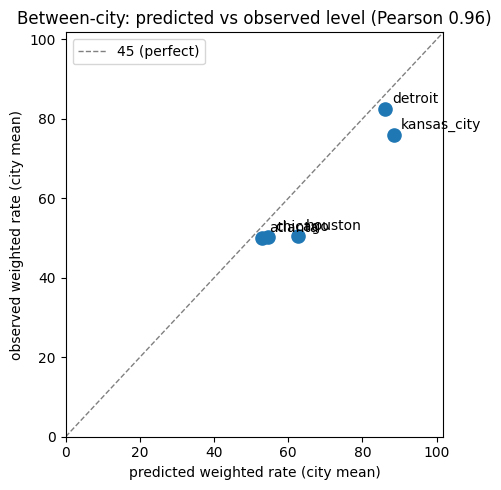

In [4]:
cm = (panel.groupby("city")
      .agg(pred=("pred", "mean"), obs=("obs", "mean"), n=("obs", "size"))
      .reindex(CITIES).reset_index())
between_r = pearsonr(cm.pred, cm.obs)[0]
between_rho = spearmanr(cm.pred, cm.obs)[0]
print(cm.to_string(index=False))
print(f"\nbetween-city Pearson = {between_r:.3f}   Spearman = {between_rho:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
lim = [0, cm[["pred", "obs"]].values.max() * 1.15]
ax.plot(lim, lim, "--", color="grey", lw=1, label="45 (perfect)")
ax.scatter(cm.pred, cm.obs, s=90, zorder=3)
for _, r in cm.iterrows():
    ax.annotate(r.city, (r.pred, r.obs), xytext=(5, 4), textcoords="offset points")
ax.set(xlim=lim, ylim=lim, xlabel="predicted weighted rate (city mean)",
       ylabel="observed weighted rate (city mean)",
       title=f"Between-city: predicted vs observed level (Pearson {between_r:.2f})")
ax.legend(); plt.tight_layout(); plt.show()

#### 4. But ~95% of the variance is *within* cities — where the fit weakens

Decompose the observed (log) weighted-rate variance into a between-city component (city
means) and a within-city component (block-to-block, city-demeaned). Then measure how well
the prediction tracks the **within-city** (city-demeaned) signal.

In [5]:
ss_tot = ((panel.lobs - panel.lobs.mean()) ** 2).sum()
ss_between = (panel.groupby("city")
              .apply(lambda g: len(g) * (g.lobs.mean() - panel.lobs.mean()) ** 2).sum())
between_share = ss_between / ss_tot

panel["lpred_dm"] = panel.lpred - panel.groupby("city").lpred.transform("mean")
panel["lobs_dm"] = panel.lobs - panel.groupby("city").lobs.transform("mean")
within_r = pearsonr(panel.lpred_dm, panel.lobs_dm)[0]

print(f"observed log-variance   between-city = {between_share:5.1%}   "
      f"within-city = {1 - between_share:5.1%}")
print(f"within-city (city-demeaned) predicted-vs-observed Pearson = {within_r:.3f}")

observed log-variance   between-city =  4.8%   within-city = 95.2%
within-city (city-demeaned) predicted-vs-observed Pearson = 0.570


#### 5. The within-city defect is **magnitude compression** (+ inconsistent rank)

Per city we report:
- **Spearman** / **log-Pearson** — does the prediction order blocks correctly within the city?
- **P90/P10 spread** for predicted vs observed — the *dynamic range*. The model squeezes
  blocks into a narrow band while real crime fans out much wider.
- **compression** = obs spread ÷ pred spread — how many times wider reality is than the
  model predicts.
- **decile lift** — observed weighted rate in the top vs bottom predicted decile
  (population-weighted); how much real crime separation the ranking actually buys.

In [6]:
def p90p10(x):
    x = x[x > 0]
    return np.percentile(x, 90) / np.percentile(x, 10)

def wmean(g, col):
    return np.average(g[col], weights=g.population)

rows = []
for city, g in panel.groupby("city"):
    g = g.copy()
    g["dec"] = pd.qcut(g.pred.rank(method="first"), 10, labels=False)
    lift = wmean(g[g.dec == 9], "obs") / wmean(g[g.dec == 0], "obs")
    pr_pred, pr_obs = p90p10(g.pred), p90p10(g.obs)
    rows.append({
        "city": city, "n": len(g),
        "spearman": spearmanr(g.pred, g.obs)[0],
        "log_pearson": pearsonr(g.lpred, g.lobs)[0],
        "pred_P90/10": pr_pred, "obs_P90/10": pr_obs,
        "compression_x": pr_obs / pr_pred, "decile_lift_x": lift,
    })
diag = pd.DataFrame(rows).set_index("city").reindex(CITIES)
diag.round(2)

,n,spearman,log_pearson,pred_P90/10,obs_P90/10,compression_x,decile_lift_x
city,,,,,,,
houston,1623,0.47,0.50,4.03,15.39,3.82,6.12
chicago,2154,0.63,0.63,4.80,16.48,3.43,6.10
atlanta,421,0.56,0.60,6.12,26.85,4.39,7.04
kansas_city,464,0.66,0.68,6.34,27.53,4.34,13.23
detroit,592,0.33,0.35,3.24,7.19,2.22,1.80


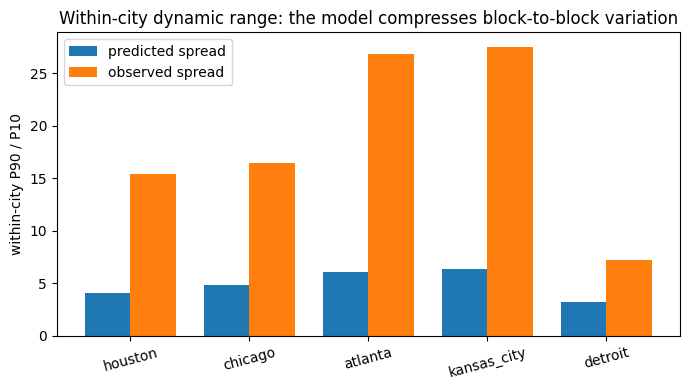

In [7]:
# Compression bar chart: predicted vs observed within-city dynamic range (P90/P10).
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(diag)); w = 0.38
ax.bar(x - w/2, diag["pred_P90/10"], w, label="predicted spread")
ax.bar(x + w/2, diag["obs_P90/10"], w, label="observed spread")
ax.set_xticks(x); ax.set_xticklabels(diag.index, rotation=15)
ax.set_ylabel("within-city P90 / P10"); ax.legend()
ax.set_title("Within-city dynamic range: the model compresses block-to-block variation")
plt.tight_layout(); plt.show()

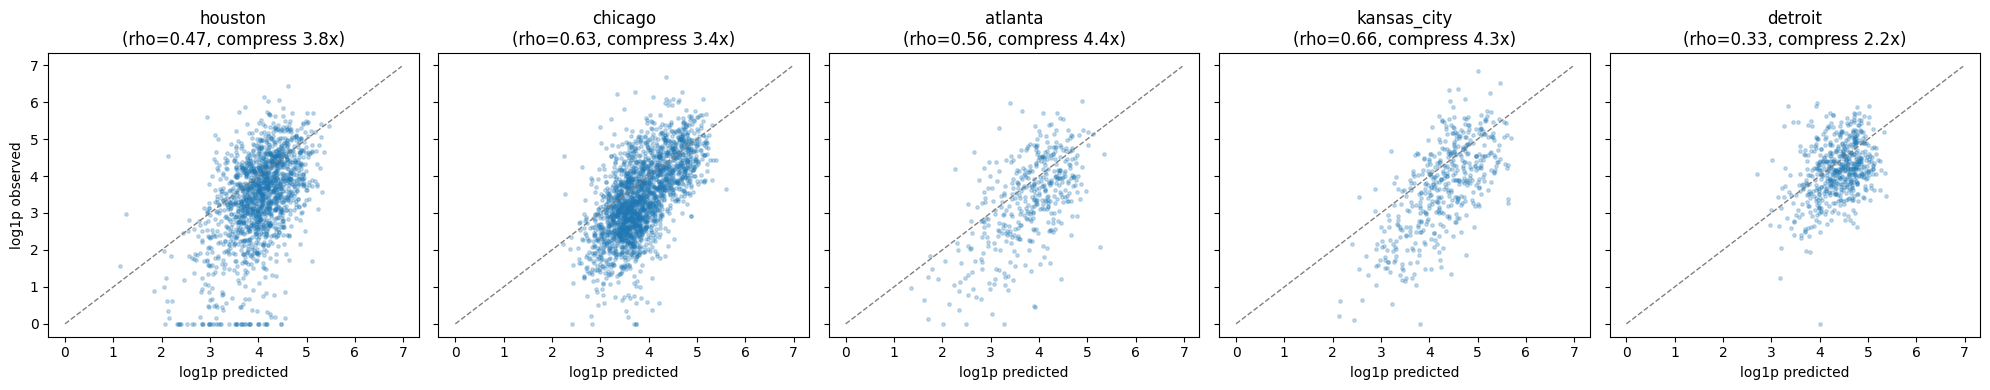

In [8]:
# Small-multiple scatter: within-city predicted vs observed (log-log), 45 line.
# Points smear vertically -> observed fans out while prediction barely moves.
fig, axes = plt.subplots(1, len(CITIES), figsize=(4 * len(CITIES), 4), sharex=True, sharey=True)
for ax, city in zip(axes, CITIES):
    g = panel[panel.city == city]
    ax.scatter(g.lpred, g.lobs, s=6, alpha=0.25)
    lim = [0, max(panel.lpred.max(), panel.lobs.max()) * 1.02]
    ax.plot(lim, lim, "--", color="grey", lw=1)
    ax.set(title=f"{city}\n(rho={diag.loc[city,'spearman']:.2f}, "
                 f"compress {diag.loc[city,'compression_x']:.1f}x)",
           xlabel="log1p predicted")
axes[0].set_ylabel("log1p observed")
plt.tight_layout(); plt.show()

#### 6. Takeaway — why we move to a city-incident, BG-aggregated target

- **Between cities the existing model is excellent.** City-mean predicted and observed
  weighted rates line up almost 1:1 (Pearson ~0.96). The agency-trained model does exactly
  what it was built to do: separate high-crime cities from low-crime ones.
- **But ~95% of the weighted-rate variance is *within* cities**, and that is the variance a
  block-group product must resolve. There the same model:
  - retains only **moderate, city-inconsistent rank** (Spearman ~0.33 in Detroit up to
    ~0.66 in Kansas City), and
  - **severely compresses magnitude** — it predicts a ~3–6x block-to-block spread where the
    observed spread is ~7–28x (2–4x too narrow), so blocks are pulled toward a city-typical
    value instead of separated. In Detroit the ranking barely separates blocks at all
    (decile lift ~1.8x vs 6–13x elsewhere).
- **Honest caveat:** the ranking is not useless — top-vs-bottom predicted-decile lift is
  6–13x in four of five cities — but the magnitude compression and the Detroit-style
  failures show it is not built for within-city discrimination.

**Conclusion.** The agency-scale target is the wrong scale for a within-city product. This
is the target/scale half of the rebuild case (predictors: `03`; target/scale: here) and
motivates training on a **city-incident, BG-aggregated weighted rate** whose explicit
objective is the within-city variation the current model leaves on the table.